In [6]:
%pip install duckdb datashader colorcet

Note: you may need to restart the kernel to use updated packages.


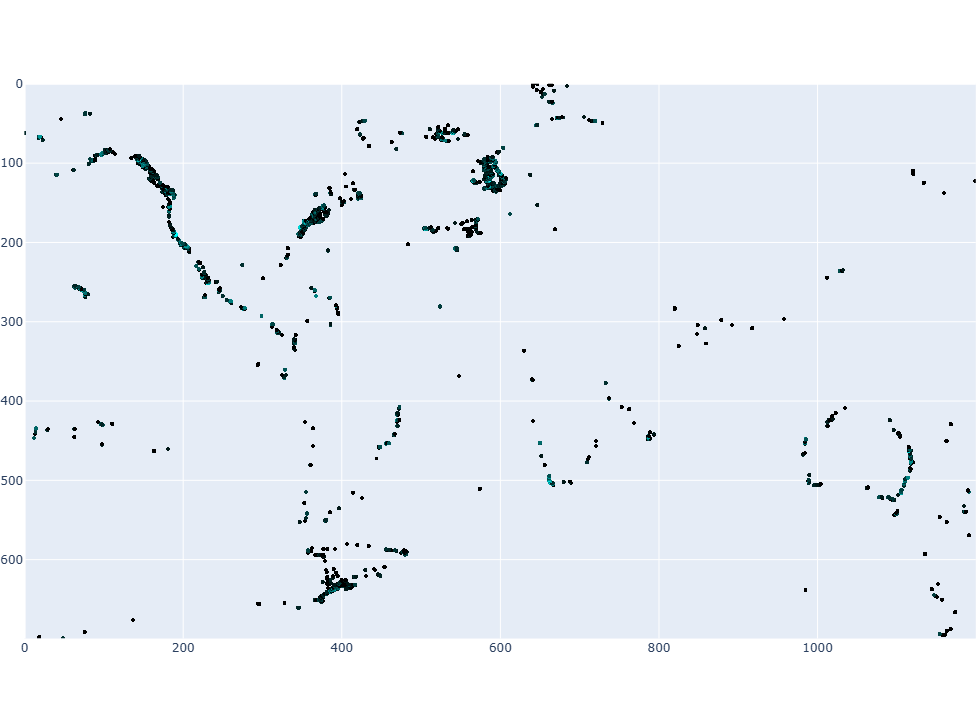

In [15]:
import duckdb, datashader as ds, datashader.transfer_functions as tf, plotly.express as px

# 1. Daten laden
path = "/mnt/shared_data/finflow/obis_raw/Cetacea/*/*.parquet"
df = duckdb.query(f"SELECT decimalLongitude as lon, decimalLatitude as lat FROM read_parquet('{path}') WHERE year(eventDate) = 2024").to_df()

# 2. Bild mit Datashader berechnen
cvs = ds.Canvas(plot_width=1200, plot_height=700)
agg = cvs.points(df, 'lon', 'lat', ds.count())
img = tf.shade(agg, cmap=["black", "cyan"], how='log')
img = tf.spread(img, px=2)

# 3. Zoombar in Plotly anzeigen
fig = px.imshow(img.to_pil())
fig.update_layout(dragmode='pan', width=1200, height=700, margin=dict(l=0,r=0,t=0,b=0))
fig.show(config={'scrollZoom': True})

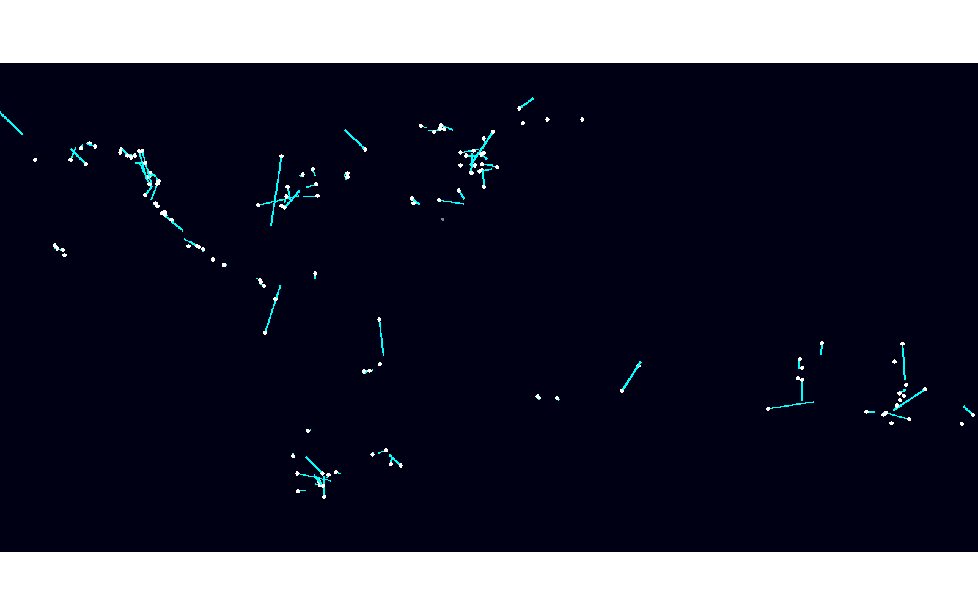

Anzahl berechneter Trends: 132


In [14]:
import duckdb
import pandas as pd
import numpy as np
import datashader as ds
import datashader.transfer_functions as tf
import plotly.express as px
from PIL import Image, ImageDraw

# ==========================================
# 1. KONFIGURATION (Hier schrauben!)
# ==========================================
JAHR = 2024
RASTER_GRAD = 3.0       # Größeres Raster = weniger, aber deutlichere Pfeile
MIN_PUNKTE = 5          # Wie viele Sichtungen müssen pro Raster da sein?
PFEIL_SKALIERUNG = 10.0 # Erhöht auf 10x, falls Bewegungen sehr klein sind
LINIEN_DICKE = 3        # Dickere Linien für bessere Sichtbarkeit

# ==========================================
# 2. DATEN LADEN & TRENDS BERECHNEN
# ==========================================
con = duckdb.connect(database=':memory:')
path_obis = "/mnt/shared_data/finflow/obis_raw/Cetacea/*/*.parquet"

# Wir berechnen die Schwerpunkte pro Halbjahr
query = f"""
WITH base AS (
    SELECT 
        decimalLongitude as lon, 
        decimalLatitude as lat,
        (FLOOR(decimalLongitude / {RASTER_GRAD}) * {RASTER_GRAD}) as grid_lon,
        (FLOOR(decimalLatitude / {RASTER_GRAD}) * {RASTER_GRAD}) as grid_lat,
        CASE WHEN month(eventDate) <= 6 THEN 'START' ELSE 'END' END as phase
    FROM read_parquet('{path_obis}')
    WHERE year(eventDate) = {JAHR}
      AND lon IS NOT NULL AND lat IS NOT NULL
)
SELECT 
    grid_lon, grid_lat,
    AVG(CASE WHEN phase = 'START' THEN lon END) as x1,
    AVG(CASE WHEN phase = 'START' THEN lat END) as y1,
    AVG(CASE WHEN phase = 'END' THEN lon END) as x2,
    AVG(CASE WHEN phase = 'END' THEN lat END) as y2
FROM base
GROUP BY grid_lon, grid_lat
HAVING COUNT(DISTINCT phase) = 2 
   AND COUNT(*) >= {MIN_PUNKTE}
"""

df_vektoren = con.execute(query).df()

# ==========================================
# 3. BILD ZEICHNEN (Pfeile erzwingen)
# ==========================================
W, H = 1600, 800
# Wir erstellen ein komplett schwarzes Bild
pil_img = Image.new("RGB", (W, H), (0, 0, 20)) # Sehr dunkles Blau
draw = ImageDraw.Draw(pil_img)

def to_px(lon, lat):
    # Standard Mercator-ähnliche Projektion für das Bild
    x = int((lon + 180) * (W / 360))
    y = int((90 - lat) * (H / 180))
    return x, y

for _, row in df_vektoren.iterrows():
    # Startpunkt im Pixel-Raum
    start_px = to_px(row['x1'], row['y1'])
    
    # Verschiebung berechnen
    dx = (row['x2'] - row['x1']) * PFEIL_SKALIERUNG
    dy = (row['y2'] - row['y1']) * PFEIL_SKALIERUNG
    
    # Endpunkt im Pixel-Raum
    end_px = to_px(row['x1'] + dx, row['y1'] + dy)
    
    # PRÜFUNG: Wenn Start und Ende fast gleich sind, zeichnen wir trotzdem eine Mindestlinie
    if start_px == end_px:
        # Kleiner Punkt, falls gar keine Bewegung da war
        draw.ellipse([start_px[0]-2, start_px[1]-2, start_px[0]+2, start_px[1]+2], fill="gray")
    else:
        # Zeichne den Pfeil (Linie)
        draw.line([start_px, end_px], fill="cyan", width=LINIEN_DICKE)
        # Markiere das Ziel mit einem weißen Punkt
        draw.ellipse([end_px[0]-3, end_px[1]-3, end_px[0]+3, end_px[1]+3], fill="white")

# ==========================================
# 4. ANZEIGE MIT ZOOM
# ==========================================
fig = px.imshow(pil_img)
fig.update_layout(
    dragmode='pan', 
    width=1200, height=600,
    margin=dict(l=0, r=0, t=0, b=0),
    xaxis=dict(visible=False), yaxis=dict(visible=False)
)
fig.show(config={'scrollZoom': True})

print(f"Anzahl berechneter Trends: {len(df_vektoren)}")